# 🎬📊 Aplicações da aula de 1 a 8: uma análise de dados real, do início ao fim

Este notebook é diferente dos anteriores: em vez de um exemplo por aula, vamos usar **um único banco de dados real** e percorrer, na ordem, **todos os conteúdos das Aulas 1 a 8** — como se fosse uma pequena análise de dados profissional, do jeito que se faz de verdade: carregar dado bagunçado, limpar, descrever, e só depois perguntar coisas mais sofisticadas sobre ele (probabilidade, variável aleatória).

O banco de dados é o **IMDb Top 250** — a lista real dos 250 filmes mais bem avaliados pelos usuários do site IMDb (a mesma lista que você pode ver em imdb.com/chart/top). Não é um exemplo inventado: são notas, votos, duração e bilheteria reais de filmes reais.

Só executar e ler, na ordem, sem entrega. No final, tem uma sugestão de projeto para você fazer o mesmo tipo de análise com um banco de dados escolhido por você.

## 0. Carregando os dados reais

Os dados abaixo foram baixados de um repositório público (Kaggle/GitHub) com a lista real do IMDb Top 250: título, ano, classificação indicativa, duração, gênero, nota, número de votos e bilheteria de cada filme. Colamos o CSV direto aqui para o notebook funcionar mesmo sem internet.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import io

DADOS_CSV = '''Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,No_of_Votes,Gross
The Shawshank Redemption,1994,A,142 min,Drama,9.3,2343110,"28,341,469"
The Godfather,1972,A,175 min,"Crime, Drama",9.2,1620367,"134,966,411"
The Dark Knight,2008,UA,152 min,"Action, Crime, Drama",9.0,2303232,"534,858,444"
The Godfather: Part II,1974,A,202 min,"Crime, Drama",9.0,1129952,"57,300,000"
12 Angry Men,1957,U,96 min,"Crime, Drama",9.0,689845,"4,360,000"
The Lord of the Rings: The Return of the King,2003,U,201 min,"Action, Adventure, Drama",8.9,1642758,"377,845,905"
Pulp Fiction,1994,A,154 min,"Crime, Drama",8.9,1826188,"107,928,762"
Schindler's List,1993,A,195 min,"Biography, Drama, History",8.9,1213505,"96,898,818"
Inception,2010,UA,148 min,"Action, Adventure, Sci-Fi",8.8,2067042,"292,576,195"
Fight Club,1999,A,139 min,Drama,8.8,1854740,"37,030,102"
The Lord of the Rings: The Fellowship of the Ring,2001,U,178 min,"Action, Adventure, Drama",8.8,1661481,"315,544,750"
Forrest Gump,1994,UA,142 min,"Drama, Romance",8.8,1809221,"330,252,182"
"Il buono, il brutto, il cattivo",1966,A,161 min,Western,8.8,688390,"6,100,000"
The Lord of the Rings: The Two Towers,2002,UA,179 min,"Action, Adventure, Drama",8.7,1485555,"342,551,365"
The Matrix,1999,A,136 min,"Action, Sci-Fi",8.7,1676426,"171,479,930"
Goodfellas,1990,A,146 min,"Biography, Crime, Drama",8.7,1020727,"46,836,394"
Star Wars: Episode V - The Empire Strikes Back,1980,UA,124 min,"Action, Adventure, Fantasy",8.7,1159315,"290,475,067"
One Flew Over the Cuckoo's Nest,1975,A,133 min,Drama,8.7,918088,"112,000,000"
Hamilton,2020,PG-13,160 min,"Biography, Drama, History",8.6,55291,
Gisaengchung,2019,A,132 min,"Comedy, Drama, Thriller",8.6,552778,"53,367,844"
Soorarai Pottru,2020,U,153 min,Drama,8.6,54995,
Interstellar,2014,UA,169 min,"Adventure, Drama, Sci-Fi",8.6,1512360,"188,020,017"
Cidade de Deus,2002,A,130 min,"Crime, Drama",8.6,699256,"7,563,397"
Sen to Chihiro no kamikakushi,2001,U,125 min,"Animation, Adventure, Family",8.6,651376,"10,055,859"
Saving Private Ryan,1998,R,169 min,"Drama, War",8.6,1235804,"216,540,909"
The Green Mile,1999,A,189 min,"Crime, Drama, Fantasy",8.6,1147794,"136,801,374"
La vita è bella,1997,U,116 min,"Comedy, Drama, Romance",8.6,623629,"57,598,247"
Se7en,1995,A,127 min,"Crime, Drama, Mystery",8.6,1445096,"100,125,643"
The Silence of the Lambs,1991,A,118 min,"Crime, Drama, Thriller",8.6,1270197,"130,742,922"
Star Wars,1977,UA,121 min,"Action, Adventure, Fantasy",8.6,1231473,"322,740,140"
Seppuku,1962,,133 min,"Action, Drama, Mystery",8.6,42004,
Shichinin no samurai,1954,U,207 min,"Action, Adventure, Drama",8.6,315744,"269,061"
It's a Wonderful Life,1946,PG,130 min,"Drama, Family, Fantasy",8.6,405801,
Joker,2019,A,122 min,"Crime, Drama, Thriller",8.5,939252,"335,451,311"
Whiplash,2014,A,106 min,"Drama, Music",8.5,717585,"13,092,000"
The Intouchables,2011,UA,112 min,"Biography, Comedy, Drama",8.5,760360,"13,182,281"
The Prestige,2006,U,130 min,"Drama, Mystery, Sci-Fi",8.5,1190259,"53,089,891"
The Departed,2006,A,151 min,"Crime, Drama, Thriller",8.5,1189773,"132,384,315"
The Pianist,2002,R,150 min,"Biography, Drama, Music",8.5,729603,"32,572,577"
Gladiator,2000,UA,155 min,"Action, Adventure, Drama",8.5,1341460,"187,705,427"
American History X,1998,R,119 min,Drama,8.5,1034705,"6,719,864"
The Usual Suspects,1995,A,106 min,"Crime, Mystery, Thriller",8.5,991208,"23,341,568"
Léon,1994,A,110 min,"Action, Crime, Drama",8.5,1035236,"19,501,238"
The Lion King,1994,U,88 min,"Animation, Adventure, Drama",8.5,942045,"422,783,777"
Terminator 2: Judgment Day,1991,U,137 min,"Action, Sci-Fi",8.5,995506,"204,843,350"
Nuovo Cinema Paradiso,1988,U,155 min,"Drama, Romance",8.5,230763,"11,990,401"
Hotaru no haka,1988,U,89 min,"Animation, Drama, War",8.5,235231,
Back to the Future,1985,U,116 min,"Adventure, Comedy, Sci-Fi",8.5,1058081,"210,609,762"
Once Upon a Time in the West,1968,U,165 min,Western,8.5,302844,"5,321,508"
Psycho,1960,A,109 min,"Horror, Mystery, Thriller",8.5,604211,"32,000,000"
Casablanca,1942,U,102 min,"Drama, Romance, War",8.5,522093,"1,024,560"
Modern Times,1936,G,87 min,"Comedy, Drama, Family",8.5,217881,"163,245"
City Lights,1931,G,87 min,"Comedy, Drama, Romance",8.5,167839,"19,181"
Capharnaüm,2018,A,126 min,Drama,8.4,62635,"1,661,096"
Ayla: The Daughter of War,2017,,125 min,"Biography, Drama, History",8.4,34112,
Vikram Vedha,2017,UA,147 min,"Action, Crime, Drama",8.4,28401,
Kimi no na wa.,2016,U,106 min,"Animation, Drama, Fantasy",8.4,194838,"5,017,246"
Dangal,2016,U,161 min,"Action, Biography, Drama",8.4,156479,"12,391,761"
Spider-Man: Into the Spider-Verse,2018,U,117 min,"Animation, Action, Adventure",8.4,375110,"190,241,310"
Avengers: Endgame,2019,UA,181 min,"Action, Adventure, Drama",8.4,809955,"858,373,000"
Avengers: Infinity War,2018,UA,149 min,"Action, Adventure, Sci-Fi",8.4,834477,"678,815,482"
Coco,2017,U,105 min,"Animation, Adventure, Family",8.4,384171,"209,726,015"
Django Unchained,2012,A,165 min,"Drama, Western",8.4,1357682,"162,805,434"
The Dark Knight Rises,2012,UA,164 min,"Action, Adventure",8.4,1516346,"448,139,099"
3 Idiots,2009,UA,170 min,"Comedy, Drama",8.4,344445,"6,532,908"
Taare Zameen Par,2007,U,165 min,"Drama, Family",8.4,168895,"1,223,869"
WALL·E,2008,U,98 min,"Animation, Adventure, Family",8.4,999790,"223,808,164"
The Lives of Others,2006,A,137 min,"Drama, Mystery, Thriller",8.4,358685,"11,286,112"
Oldeuboi,2003,A,101 min,"Action, Drama, Mystery",8.4,515451,"707,481"
Memento,2000,UA,113 min,"Mystery, Thriller",8.4,1125712,"25,544,867"
Mononoke-hime,1997,U,134 min,"Animation, Action, Adventure",8.4,343171,"2,375,308"
Once Upon a Time in America,1984,A,229 min,"Crime, Drama",8.4,311365,"5,321,508"
Raiders of the Lost Ark,1981,A,115 min,"Action, Adventure",8.4,884112,"248,159,971"
The Shining,1980,A,146 min,"Drama, Horror",8.4,898237,"44,017,374"
Apocalypse Now,1979,R,147 min,"Drama, Mystery, War",8.4,606398,"83,471,511"
Alien,1979,R,117 min,"Horror, Sci-Fi",8.4,787806,"78,900,000"
Anand,1971,U,122 min,"Drama, Musical",8.4,30273,
Tengoku to jigoku,1963,,143 min,"Crime, Drama, Mystery",8.4,34357,
Dr. Strangelove or: How I Learned to Stop Worrying and Love the Bomb,1964,A,95 min,Comedy,8.4,450474,"275,902"
Witness for the Prosecution,1957,U,116 min,"Crime, Drama, Mystery",8.4,108862,"8,175,000"
Paths of Glory,1957,A,88 min,"Drama, War",8.4,178092,
Rear Window,1954,U,112 min,"Mystery, Thriller",8.4,444074,"36,764,313"
Sunset Blvd.,1950,Passed,110 min,"Drama, Film-Noir",8.4,201632,
The Great Dictator,1940,Passed,125 min,"Comedy, Drama, War",8.4,203150,"288,475"
1917,2019,R,119 min,"Drama, Thriller, War",8.3,425844,"159,227,644"
Tumbbad,2018,A,104 min,"Drama, Fantasy, Horror",8.3,27793,
Andhadhun,2018,UA,139 min,"Crime, Drama, Music",8.3,71875,"1,373,943"
Drishyam,2013,U,160 min,"Crime, Drama, Thriller",8.3,30722,
Jagten,2012,R,115 min,Drama,8.3,281623,"687,185"
Jodaeiye Nader az Simin,2011,PG-13,123 min,Drama,8.3,220002,"7,098,492"
Incendies,2010,R,131 min,"Drama, Mystery, War",8.3,150023,"6,857,096"
Miracle in cell NO.7,2019,TV-14,132 min,Drama,8.3,33935,
Babam ve Oglum,2005,,112 min,"Drama, Family",8.3,78925,
Inglourious Basterds,2009,A,153 min,"Adventure, Drama, War",8.3,1267869,"120,540,719"
Eternal Sunshine of the Spotless Mind,2004,UA,108 min,"Drama, Romance, Sci-Fi",8.3,911664,"34,400,301"
Amélie,2001,U,122 min,"Comedy, Romance",8.3,703810,"33,225,499"
Snatch,2000,UA,104 min,"Comedy, Crime",8.3,782001,"30,328,156"
Requiem for a Dream,2000,A,102 min,Drama,8.3,766870,"3,635,482"
American Beauty,1999,UA,122 min,Drama,8.3,1069738,"130,096,601"
Good Will Hunting,1997,U,126 min,"Drama, Romance",8.3,861606,"138,433,435"
Bacheha-Ye aseman,1997,PG,89 min,"Drama, Family, Sport",8.3,65341,"933,933"
Toy Story,1995,U,81 min,"Animation, Adventure, Comedy",8.3,887429,"191,796,233"
Braveheart,1995,A,178 min,"Biography, Drama, History",8.3,959181,"75,600,000"
Reservoir Dogs,1992,R,99 min,"Crime, Drama, Thriller",8.3,918562,"2,832,029"
Full Metal Jacket,1987,UA,116 min,"Drama, War",8.3,675146,"46,357,676"
Idi i smotri,1985,A,142 min,"Drama, Thriller, War",8.3,59056,
Aliens,1986,U,137 min,"Action, Adventure, Sci-Fi",8.3,652719,"85,160,248"
Amadeus,1984,R,160 min,"Biography, Drama, History",8.3,369007,"51,973,029"
Scarface,1983,A,170 min,"Crime, Drama",8.3,740911,"45,598,982"
Star Wars: Episode VI - Return of the Jedi,1983,U,131 min,"Action, Adventure, Fantasy",8.3,950470,"309,125,409"
Das Boot,1981,R,149 min,"Adventure, Drama, Thriller",8.3,231855,"11,487,676"
Taxi Driver,1976,A,114 min,"Crime, Drama",8.3,724636,"28,262,574"
The Sting,1973,U,129 min,"Comedy, Crime, Drama",8.3,241513,"159,600,000"
A Clockwork Orange,1971,A,136 min,"Crime, Drama, Sci-Fi",8.3,757904,"6,207,725"
2001: A Space Odyssey,1968,U,149 min,"Adventure, Sci-Fi",8.3,603517,"56,954,992"
Per qualche dollaro in più,1965,U,132 min,Western,8.3,232772,"15,000,000"
Lawrence of Arabia,1962,U,228 min,"Adventure, Biography, Drama",8.3,268085,"44,824,144"
The Apartment,1960,U,125 min,"Comedy, Drama, Romance",8.3,164363,"18,600,000"
North by Northwest,1959,U,136 min,"Adventure, Mystery, Thriller",8.3,299198,"13,275,000"
Vertigo,1958,A,128 min,"Mystery, Romance, Thriller",8.3,364368,"3,200,000"
Singin' in the Rain,1952,G,103 min,"Comedy, Musical, Romance",8.3,218957,"8,819,028"
Ikiru,1952,,143 min,Drama,8.3,68463,"55,240"
Ladri di biciclette,1948,,89 min,Drama,8.3,146427,"332,930"
Double Indemnity,1944,Passed,107 min,"Crime, Drama, Film-Noir",8.3,143525,"5,720,000"
Citizen Kane,1941,UA,119 min,"Drama, Mystery",8.3,403351,"1,585,634"
M - Eine Stadt sucht einen Mörder,1931,Passed,117 min,"Crime, Mystery, Thriller",8.3,143434,"28,877"
Metropolis,1927,,153 min,"Drama, Sci-Fi",8.3,159992,"1,236,166"
The Kid,1921,Passed,68 min,"Comedy, Drama, Family",8.3,113314,"5,450,000"
Chhichhore,2019,UA,143 min,"Comedy, Drama",8.2,33893,"898,575"
Uri: The Surgical Strike,2018,UA,138 min,"Action, Drama, War",8.2,43444,"4,186,168"
K.G.F: Chapter 1,2018,UA,156 min,"Action, Drama",8.2,36680,
Green Book,2018,UA,130 min,"Biography, Comedy, Drama",8.2,377884,"85,080,171"
"Three Billboards Outside Ebbing, Missouri",2017,A,115 min,"Comedy, Crime, Drama",8.2,432610,"54,513,740"
Talvar,2015,UA,132 min,"Crime, Drama, Mystery",8.2,31142,"342,370"
Baahubali 2: The Conclusion,2017,UA,167 min,"Action, Drama",8.2,75348,"20,186,659"
Klaus,2019,PG,96 min,"Animation, Adventure, Comedy",8.2,104761,
Drishyam,2015,UA,163 min,"Crime, Drama, Mystery",8.2,70367,"739,478"
Queen,2013,UA,146 min,"Adventure, Comedy, Drama",8.2,60701,"1,429,534"
Mandariinid,2013,,87 min,"Drama, War",8.2,40382,"144,501"
Bhaag Milkha Bhaag,2013,U,186 min,"Biography, Drama, Sport",8.2,61137,"1,626,289"
Gangs of Wasseypur,2012,A,321 min,"Action, Comedy, Crime",8.2,82365,
Udaan,2010,UA,134 min,Drama,8.2,42341,"7,461"
Paan Singh Tomar,2012,UA,135 min,"Action, Biography, Crime",8.2,33237,"39,567"
El secreto de sus ojos,2009,R,129 min,"Drama, Mystery, Romance",8.2,193217,"6,391,436"
Warrior,2011,UA,140 min,"Action, Drama, Sport",8.2,435950,"13,657,115"
Shutter Island,2010,A,138 min,"Mystery, Thriller",8.2,1129894,"128,012,934"
Up,2009,U,96 min,"Animation, Adventure, Comedy",8.2,935507,"293,004,164"
The Wolf of Wall Street,2013,A,180 min,"Biography, Crime, Drama",8.2,1187498,"116,900,694"
Chak De! India,2007,U,153 min,"Drama, Family, Sport",8.2,74129,"1,113,541"
There Will Be Blood,2007,A,158 min,Drama,8.2,517359,"40,222,514"
Pan's Labyrinth,2006,UA,118 min,"Drama, Fantasy, War",8.2,618623,"37,634,615"
Toy Story 3,2010,U,103 min,"Animation, Adventure, Comedy",8.2,757032,"415,004,880"
V for Vendetta,2005,A,132 min,"Action, Drama, Sci-Fi",8.2,1032749,"70,511,035"
Rang De Basanti,2006,UA,167 min,"Comedy, Crime, Drama",8.2,111937,"2,197,331"
Black,2005,U,122 min,Drama,8.2,33354,"733,094"
Batman Begins,2005,UA,140 min,"Action, Adventure",8.2,1308302,"206,852,432"
"Swades: We, the People",2004,U,210 min,Drama,8.2,83005,"1,223,240"
Der Untergang,2004,R,156 min,"Biography, Drama, History",8.2,331308,"5,509,040"
Hauru no ugoku shiro,2004,U,119 min,"Animation, Adventure, Family",8.2,333915,"4,711,096"
A Beautiful Mind,2001,UA,135 min,"Biography, Drama",8.2,848920,"170,742,341"
Hera Pheri,2000,U,156 min,"Action, Comedy, Crime",8.2,57057,
"Lock, Stock and Two Smoking Barrels",1998,A,107 min,"Action, Comedy, Crime",8.2,535216,"3,897,569"
L.A. Confidential,1997,A,138 min,"Crime, Drama, Mystery",8.2,531967,"64,616,940"
Eskiya,1996,,128 min,"Crime, Drama, Thriller",8.2,64118,
Heat,1995,A,170 min,"Crime, Drama, Thriller",8.2,577113,"67,436,818"
Casino,1995,A,178 min,"Crime, Drama",8.2,466276,"42,438,300"
Andaz Apna Apna,1994,U,160 min,"Action, Comedy, Romance",8.2,49300,
Unforgiven,1992,A,130 min,"Drama, Western",8.2,375935,"101,157,447"
Indiana Jones and the Last Crusade,1989,U,127 min,"Action, Adventure",8.2,692366,"197,171,806"
Dom za vesanje,1988,R,142 min,"Comedy, Crime, Drama",8.2,26402,"280,015"
Tonari no Totoro,1988,U,86 min,"Animation, Family, Fantasy",8.2,291180,"1,105,564"
Die Hard,1988,A,132 min,"Action, Thriller",8.2,793164,"83,008,852"
Ran,1985,U,162 min,"Action, Drama, War",8.2,112505,"4,135,750"
Raging Bull,1980,A,129 min,"Biography, Drama, Sport",8.2,321860,"23,383,987"
Stalker,1979,U,162 min,"Drama, Sci-Fi",8.2,116945,"234,723"
Höstsonaten,1978,U,99 min,"Drama, Music",8.2,26875,
The Message,1976,PG,177 min,"Biography, Drama, History",8.2,43885,
Sholay,1975,U,204 min,"Action, Adventure, Comedy",8.2,51284,
Monty Python and the Holy Grail,1975,PG,91 min,"Adventure, Comedy, Fantasy",8.2,500875,"1,229,197"
The Great Escape,1963,U,172 min,"Adventure, Drama, History",8.2,224730,"12,100,000"
To Kill a Mockingbird,1962,U,129 min,"Crime, Drama",8.2,293811,
Yôjinbô,1961,,110 min,"Action, Drama, Thriller",8.2,111244,
Judgment at Nuremberg,1961,A,179 min,"Drama, War",8.2,69458,
Some Like It Hot,1959,U,121 min,"Comedy, Music, Romance",8.2,243943,"25,000,000"
Smultronstället,1957,U,91 min,"Drama, Romance",8.2,96381,
Det sjunde inseglet,1957,A,96 min,"Drama, Fantasy, History",8.2,164939,
Du rififi chez les hommes,1955,,118 min,"Crime, Drama, Thriller",8.2,28810,"57,226"
Dial M for Murder,1954,A,105 min,"Crime, Thriller",8.2,158335,"12,562"
Tôkyô monogatari,1953,U,136 min,Drama,8.2,53153,
Rashômon,1950,,88 min,"Crime, Drama, Mystery",8.2,152572,"96,568"
All About Eve,1950,Passed,138 min,Drama,8.2,120539,"10,177"
The Treasure of the Sierra Madre,1948,Passed,126 min,"Adventure, Drama, Western",8.2,114304,"5,014,000"
To Be or Not to Be,1942,Passed,99 min,"Comedy, War",8.2,29915,
The Gold Rush,1925,Passed,95 min,"Adventure, Comedy, Drama",8.2,101053,"5,450,000"
Sherlock Jr.,1924,Passed,45 min,"Action, Comedy, Romance",8.2,41985,"977,375"
Portrait de la jeune fille en feu,2019,R,122 min,"Drama, Romance",8.1,63134,"3,759,854"
Pink,2016,UA,136 min,"Drama, Thriller",8.1,39216,"1,241,223"
Koe no katachi,2016,16,130 min,"Animation, Drama, Family",8.1,47708,
Contratiempo,2016,TV-MA,106 min,"Crime, Drama, Mystery",8.1,141516,
Ah-ga-ssi,2016,A,145 min,"Drama, Romance, Thriller",8.1,113649,"2,006,788"
Mommy,2014,R,139 min,Drama,8.1,50700,"3,492,754"
Haider,2014,UA,160 min,"Action, Crime, Drama",8.1,50445,"901,610"
Logan,2017,A,137 min,"Action, Drama, Sci-Fi",8.1,647884,"226,277,068"
Room,2015,R,118 min,"Drama, Thriller",8.1,371538,"14,677,674"
Relatos salvajes,2014,R,122 min,"Comedy, Drama, Thriller",8.1,177059,"3,107,072"
Soul,2020,U,100 min,"Animation, Adventure, Comedy",8.1,159171,
Kis Uykusu,2014,,196 min,Drama,8.1,46547,"165,520"
PK,2014,UA,153 min,"Comedy, Drama, Musical",8.1,163061,"10,616,104"
OMG: Oh My God!,2012,U,125 min,"Comedy, Drama, Fantasy",8.1,51739,"923,221"
The Grand Budapest Hotel,2014,UA,99 min,"Adventure, Comedy, Crime",8.1,707630,"59,100,318"
Gone Girl,2014,A,149 min,"Drama, Mystery, Thriller",8.1,859695,"167,767,189"
Ôkami kodomo no Ame to Yuki,2012,U,117 min,"Animation, Drama, Fantasy",8.1,38803,
Hacksaw Ridge,2016,A,139 min,"Biography, Drama, History",8.1,435928,"67,209,615"
Inside Out,2015,U,95 min,"Animation, Adventure, Comedy",8.1,616228,"356,461,711"
Barfi!,2012,U,151 min,"Comedy, Drama, Romance",8.1,75721,"2,804,874"
12 Years a Slave,2013,A,134 min,"Biography, Drama, History",8.1,640533,"56,671,993"
Rush,2013,UA,123 min,"Action, Biography, Drama",8.1,432811,"26,947,624"
Ford v Ferrari,2019,UA,152 min,"Action, Biography, Drama",8.1,291289,"117,624,028"
Spotlight,2015,A,129 min,"Biography, Crime, Drama",8.1,420316,"45,055,776"
Song of the Sea,2014,PG,93 min,"Animation, Adventure, Drama",8.1,51679,"857,524"
Kahaani,2012,UA,122 min,"Mystery, Thriller",8.1,57806,"1,035,953"
Zindagi Na Milegi Dobara,2011,U,155 min,"Comedy, Drama",8.1,67927,"3,108,485"
Prisoners,2013,A,153 min,"Crime, Drama, Mystery",8.1,601149,"61,002,302"
Mad Max: Fury Road,2015,UA,120 min,"Action, Adventure, Sci-Fi",8.1,882316,"154,058,340"
A Wednesday,2008,UA,104 min,"Action, Crime, Drama",8.1,73891,
Gran Torino,2008,R,116 min,Drama,8.1,720450,"148,095,302"
Harry Potter and the Deathly Hallows: Part 2,2011,UA,130 min,"Adventure, Drama, Fantasy",8.1,764493,"381,011,219"
Okuribito,2008,PG-13,130 min,"Drama, Music",8.1,48582,"1,498,210"
Hachi: A Dog's Tale,2009,G,93 min,"Biography, Drama, Family",8.1,253575,
Mary and Max,2009,,92 min,"Animation, Comedy, Drama",8.1,164462,
How to Train Your Dragon,2010,U,98 min,"Animation, Action, Adventure",8.1,666773,"217,581,231"
Into the Wild,2007,R,148 min,"Adventure, Biography, Drama",8.1,572921,"18,354,356"
No Country for Old Men,2007,R,122 min,"Crime, Drama, Thriller",8.1,856916,"74,283,625"
Lage Raho Munna Bhai,2006,U,144 min,"Comedy, Drama, Romance",8.1,43137,"2,217,561"
Million Dollar Baby,2004,UA,132 min,"Drama, Sport",8.1,635975,"100,492,203"
Hotel Rwanda,2004,PG-13,121 min,"Biography, Drama, History",8.1,334320,"23,530,892"
Taegukgi hwinalrimyeo,2004,R,140 min,"Action, Drama, War",8.1,37820,"1,111,061"
Before Sunset,2004,R,80 min,"Drama, Romance",8.1,236311,"5,820,649"
Munna Bhai M.B.B.S.,2003,U,156 min,"Comedy, Drama, Musical",8.1,73992,
Salinui chueok,2003,UA,131 min,"Crime, Drama, Mystery",8.1,139558,"14,131"
Dil Chahta Hai,2001,Unrated,183 min,"Comedy, Drama, Romance",8.1,66803,"300,000"
Kill Bill: Vol. 1,2003,R,111 min,"Action, Crime, Drama",8.1,1000639,"70,099,045"
Finding Nemo,2003,U,100 min,"Animation, Adventure, Comedy",8.1,949565,"380,843,261"
Catch Me If You Can,2002,A,141 min,"Biography, Crime, Drama",8.1,832846,"164,615,351"
Amores perros,2000,A,154 min,"Drama, Thriller",8.1,223741,"5,383,834"
"Monsters, Inc.",2001,U,92 min,"Animation, Adventure, Comedy",8.1,815505,"289,916,256"
"Shin seiki Evangelion Gekijô-ban: Air/Magokoro wo, kimi ni",1997,UA,87 min,"Animation, Action, Drama",8.1,38847,
Lagaan: Once Upon a Time in India,2001,U,224 min,"Adventure, Drama, Musical",8.1,105036,"70,147"
The Sixth Sense,1999,A,107 min,"Drama, Mystery, Thriller",8.1,911573,"293,506,292"
La leggenda del pianista sull'oceano,1998,U,169 min,"Drama, Music, Romance",8.1,59020,"259,127"
'''

df = pd.read_csv(io.StringIO(DADOS_CSV))
print(f"Total de filmes: {len(df)}")
df.head()

Total de filmes: 250


,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,No_of_Votes,Gross
0,The Shawshank Redemption,1994,A,142 min,Drama,9.3,2343110,"28,341,469"
1,The Godfather,1972,A,175 min,"Crime, Drama",9.2,1620367,"134,966,411"
2,The Dark Knight,2008,UA,152 min,"Action, Crime, Drama",9.0,2303232,"534,858,444"
3,The Godfather: Part II,1974,A,202 min,"Crime, Drama",9.0,1129952,"57,300,000"
4,12 Angry Men,1957,U,96 min,"Crime, Drama",9.0,689845,"4,360,000"


## 1. Limpando os dados (dado real vem bagunçado)

Repare que várias colunas não estão prontas para conta: `Runtime` é texto ("142 min"), `Gross` (bilheteria) tem vírgula como separador de milhar e **41 filmes sem esse dado** (bilheteria não é sempre divulgada), e `Genre` às vezes tem mais de um gênero na mesma célula ("Crime, Drama"). Vamos arrumar cada uma.

In [2]:
df["runtime_min"] = df["Runtime"].str.replace(" min", "", regex=False).astype(int)
df["gross_usd"] = pd.to_numeric(df["Gross"].str.replace(",", "", regex=False), errors="coerce")
df["genero_principal"] = df["Genre"].str.split(",").str[0].str.strip()

print(f"Filmes sem bilheteria registrada: {df['gross_usd'].isna().sum()} de {len(df)}")
print(f"Duração: de {df['runtime_min'].min()} a {df['runtime_min'].max()} minutos")
df[["Series_Title", "runtime_min", "gross_usd", "genero_principal"]].head()

Filmes sem bilheteria registrada: 41 de 250
Duração: de 45 a 321 minutos


,Series_Title,runtime_min,gross_usd,genero_principal
0,The Shawshank Redemption,142,28341469.0,Drama
1,The Godfather,175,134966411.0,Crime
2,The Dark Knight,152,534858444.0,Action
3,The Godfather: Part II,202,57300000.0,Crime
4,12 Angry Men,96,4360000.0,Crime


**Repare também** que a coluna `Certificate` (classificação indicativa) mistura sistemas de classificação de países diferentes (americano: `PG-13`, `R`, `G`...; indiano: `U`, `UA`, `A`...) e tem 14 filmes sem essa informação — isso acontece porque o IMDb é um site usado no mundo todo. Por isso, vamos tratar essa coluna como qualitativa nominal (sem tentar montar uma ordem única entre os dois sistemas), e é um bom lembrete: **sempre olhe os valores únicos de uma coluna antes de assumir que ela é "limpa"**.

## Aula 1 — Classificando variáveis, frequência e gráficos

- `genero_principal` → qualitativa **nominal**
- `Certificate` → qualitativa nominal (ver observação acima sobre a mistura de sistemas)
- `Released_Year` → quantitativa **discreta**
- `runtime_min`, `IMDB_Rating`, `No_of_Votes`, `gross_usd` → quantitativas **contínuas**

In [3]:
freq_absoluta = df["genero_principal"].value_counts()
freq_relativa = df["genero_principal"].value_counts(normalize=True).round(3)
tabela_frequencia = pd.DataFrame({"Frequência absoluta": freq_absoluta, "Frequência relativa": freq_relativa})
tabela_frequencia

,Frequência absoluta,Frequência relativa
genero_principal,,
Drama,69,0.276
Action,47,0.188
Crime,36,0.144
Comedy,27,0.108
Animation,24,0.096
Biography,21,0.084
Adventure,16,0.064
Mystery,5,0.020
Western,3,0.012


### Gráfico de barras — filmes por gênero principal

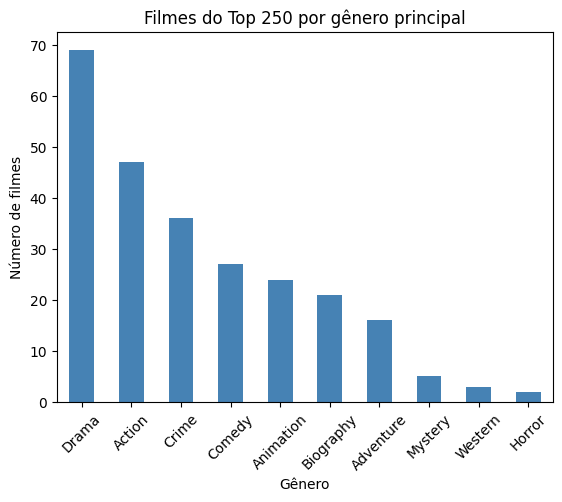

In [4]:
tabela_frequencia["Frequência absoluta"].plot(kind="bar", color="steelblue")
plt.title("Filmes do Top 250 por gênero principal")
plt.ylabel("Número de filmes")
plt.xlabel("Gênero")
plt.xticks(rotation=45)
plt.show()

### Gráfico de setores — agrupando os gêneros menores em "Outros"

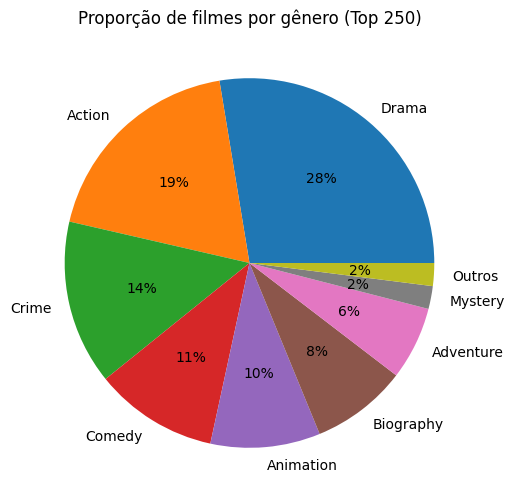

In [5]:
freq_pizza = freq_absoluta.copy()
pequenos = freq_pizza[freq_pizza < 5].sum()
freq_pizza = freq_pizza[freq_pizza >= 5]
freq_pizza["Outros"] = pequenos

freq_pizza.plot(kind="pie", autopct="%1.0f%%", ylabel="", figsize=(6, 6))
plt.title("Proporção de filmes por gênero (Top 250)")
plt.show()

### Dispersão unidimensional — duração dos filmes

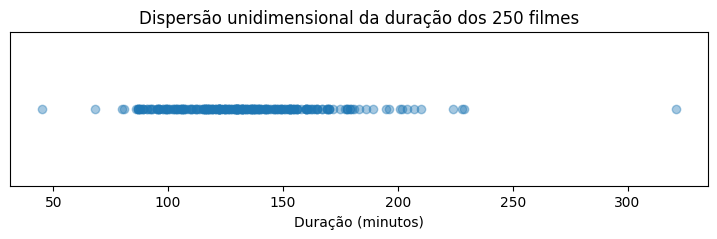

In [6]:
plt.figure(figsize=(9, 2))
plt.scatter(df["runtime_min"], [1] * len(df), alpha=0.4)
plt.yticks([])
plt.xlabel("Duração (minutos)")
plt.title("Dispersão unidimensional da duração dos 250 filmes")
plt.show()

### Histograma — distribuição das notas

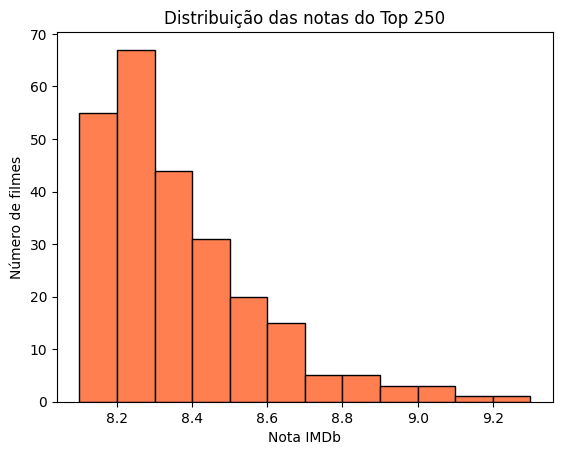

In [7]:
plt.hist(df["IMDB_Rating"], bins=12, color="coral", edgecolor="black")
plt.xlabel("Nota IMDb")
plt.ylabel("Número de filmes")
plt.title("Distribuição das notas do Top 250")
plt.show()

### Ramo-e-folhas — em que década os filmes foram lançados

Ramo = década (192, 193, ..., 202); folha = último dígito do ano.

In [8]:
from collections import defaultdict

ramos = defaultdict(list)
for ano in sorted(df["Released_Year"]):
    ramo, folha = divmod(ano, 10)
    ramos[ramo].append(str(folha))

print("Década | Anos")
print("-------+" + "-" * 40)
for ramo in sorted(ramos):
    print(f"{ramo*10:>6} | " + " ".join(ramos[ramo]))

Década | Anos
-------+----------------------------------------
  1920 | 1 4 5 7
  1930 | 1 1 6
  1940 | 0 1 2 2 4 6 8 8
  1950 | 0 0 0 2 2 3 4 4 4 5 7 7 7 7 7 8 9 9
  1960 | 0 0 1 1 2 2 2 3 3 4 5 6 8 8
  1970 | 1 1 2 3 4 5 5 5 6 6 7 8 9 9 9
  1980 | 0 0 0 1 1 3 3 4 4 5 5 5 6 7 8 8 8 8 8 9
  1990 | 0 1 1 2 2 3 4 4 4 4 4 4 5 5 5 5 5 5 6 7 7 7 7 7 7 8 8 8 8 9 9 9 9 9
  2000 | 0 0 0 0 0 0 1 1 1 1 1 1 1 2 2 2 2 3 3 3 3 3 3 4 4 4 4 4 4 4 4 5 5 5 5 6 6 6 6 6 6 7 7 7 7 7 8 8 8 8 8 9 9 9 9 9 9
  2010 | 0 0 0 0 0 0 1 1 1 1 1 2 2 2 2 2 2 2 2 2 3 3 3 3 3 3 3 3 4 4 4 4 4 4 4 4 4 4 5 5 5 5 5 5 6 6 6 6 6 6 6 7 7 7 7 7 7 8 8 8 8 8 8 8 8 9 9 9 9 9 9 9 9 9
  2020 | 0 0 0


**Repare**: a maior concentração de filmes do Top 250 é das décadas de 2000 e 2010 — não necessariamente porque os filmes recentes são "melhores", mas porque o IMDb tem muito mais usuários (e portanto mais votos) avaliando filmes recentes do que filmes de 1930.

### Medidas de posição da nota

In [9]:
media = df["IMDB_Rating"].mean()
mediana = df["IMDB_Rating"].median()
moda = df["IMDB_Rating"].mode()[0]

print(f"Média:   {media:.3f}")
print(f"Mediana: {mediana:.3f}")
print(f"Moda:    {moda:.3f}")

Média:   8.317
Mediana: 8.300
Moda:    8.200


## Aula 2 — Dispersão, quantis e box plot

### Desvio médio e variância da nota (calculados na mão, como na aula)

In [10]:
nota = df["IMDB_Rating"]
desvios = nota - nota.mean()
desvio_medio = desvios.abs().mean()
variancia = (desvios ** 2).mean()

print(f"Desvio médio: {desvio_medio:.4f}")
print(f"Variância:    {variancia:.4f}")

Desvio médio: 0.1639
Variância:    0.0467


### Quantis da duração

In [11]:
q1 = df["runtime_min"].quantile(0.25)
q2 = df["runtime_min"].quantile(0.50)
q3 = df["runtime_min"].quantile(0.75)

print(f"Q1: {q1:.1f} min   Q2 (mediana): {q2:.1f} min   Q3: {q3:.1f} min   IQR: {q3-q1:.1f} min")

Q1: 113.2 min   Q2 (mediana): 130.5 min   Q3: 152.0 min   IQR: 38.8 min


### Box plot da duração

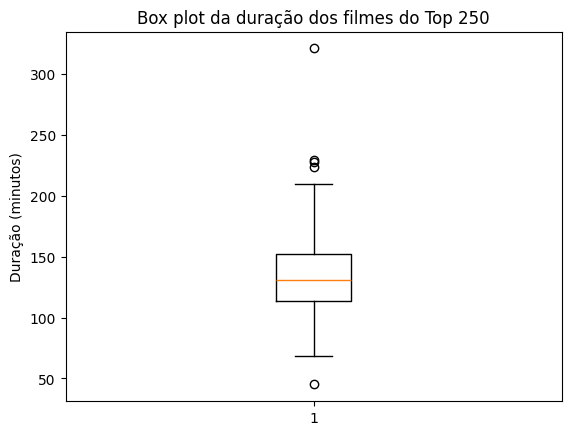

In [12]:
plt.boxplot(df["runtime_min"])
plt.ylabel("Duração (minutos)")
plt.title("Box plot da duração dos filmes do Top 250")
plt.show()

### Simetria: nota (mais simétrica) vs. número de votos (bem assimétrica)

Bilheteria e número de votos são variáveis clássicas de "efeito blockbuster": poucos filmes concentram a maior parte dos votos/bilheteria, puxando a média bem para cima da mediana.

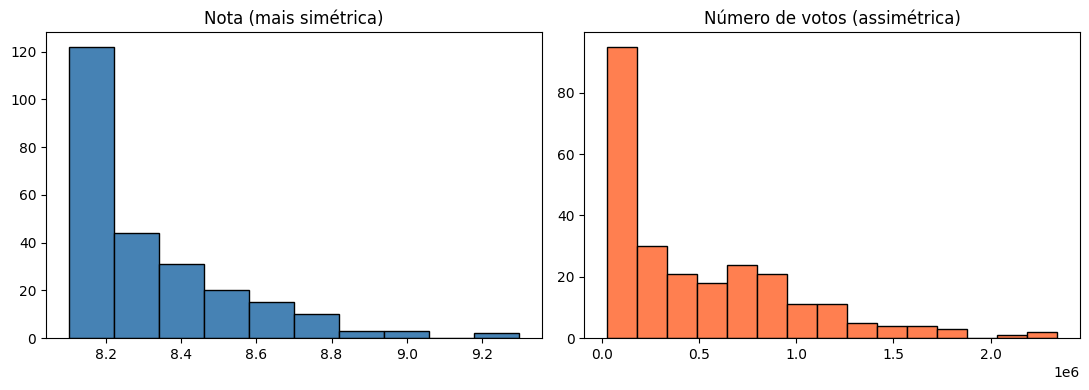

Nota          — média: 8.32   mediana: 8.30
Nº de votos   — média: 502,340   mediana: 338,746


In [13]:
fig, eixos = plt.subplots(1, 2, figsize=(11, 4))

eixos[0].hist(df["IMDB_Rating"], bins=10, color="steelblue", edgecolor="black")
eixos[0].set_title("Nota (mais simétrica)")

eixos[1].hist(df["No_of_Votes"], bins=15, color="coral", edgecolor="black")
eixos[1].set_title("Número de votos (assimétrica)")

plt.tight_layout()
plt.show()

print(f"Nota          — média: {df['IMDB_Rating'].mean():.2f}   mediana: {df['IMDB_Rating'].median():.2f}")
print(f"Nº de votos   — média: {df['No_of_Votes'].mean():,.0f}   mediana: {df['No_of_Votes'].median():,.0f}")

### Box plot da nota, por gênero (só os 5 gêneros mais frequentes)

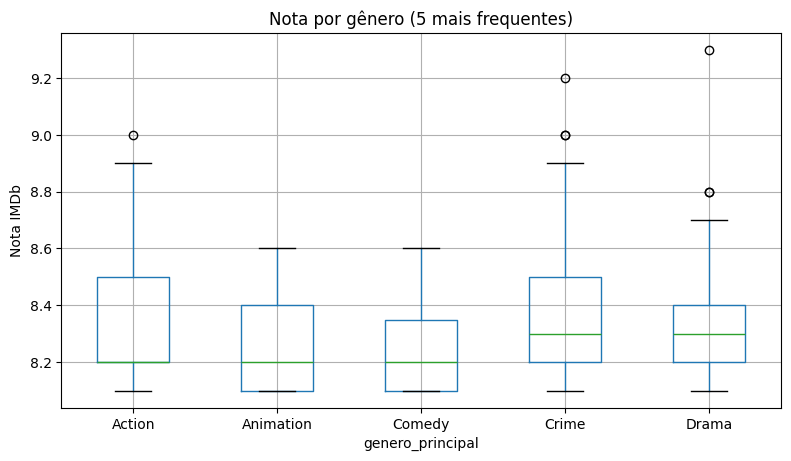

In [14]:
generos_top5 = freq_absoluta.head(5).index
df_top5 = df[df["genero_principal"].isin(generos_top5)]

df_top5.boxplot(column="IMDB_Rating", by="genero_principal", figsize=(9, 5))
plt.title("Nota por gênero (5 mais frequentes)")
plt.suptitle("")
plt.ylabel("Nota IMDb")
plt.show()

## Aula 3 — Espaço amostral e eventos

Experimento: sortear um filme aleatoriamente entre os 250. Evento de interesse: **A = "o filme é Drama"**.

In [15]:
eh_drama = df["genero_principal"] == "Drama"
p_drama = eh_drama.mean()

print(f"Espaço amostral: {len(df)} filmes")
print(f"Evento A (é Drama): {eh_drama.sum()} filmes")
print(f"P(A) = {eh_drama.sum()}/{len(df)} = {p_drama:.3f}")

Espaço amostral: 250 filmes
Evento A (é Drama): 69 filmes
P(A) = 69/250 = 0.276


### Conferindo por simulação (sorteio com reposição, 200.000 vezes)

In [16]:
rng = np.random.default_rng(0)
sorteios = rng.choice(eh_drama.to_numpy(), size=200_000, replace=True)

print(f"Frequência relativa simulada de 'Drama': {sorteios.mean():.3f}")
print(f"Proporção real no Top 250:              {p_drama:.3f}")

Frequência relativa simulada de 'Drama': 0.276
Proporção real no Top 250:              0.276


## Aula 4 — Técnicas de contagem

### Maratona de 3 filmes, importando a ordem (arranjo)

In [17]:
import math

n = len(df)
formas_arranjo = math.perm(n, 3)
print(f"De quantas formas dá para escolher 3 filmes, em ordem, entre os {n}: {formas_arranjo:,}")

De quantas formas dá para escolher 3 filmes, em ordem, entre os 250: 15,438,000


### Grupo de 3 filmes, sem importar a ordem (combinação)

In [18]:
formas_combinacao = math.comb(n, 3)
print(f"De quantas formas dá para escolher um grupo de 3 filmes (sem ordem): {formas_combinacao:,}")
print(f"Confere: {formas_arranjo:,} / 3! = {formas_arranjo // math.factorial(3):,}")

De quantas formas dá para escolher um grupo de 3 filmes (sem ordem): 2,573,000
Confere: 15,438,000 / 3! = 2,573,000


### O exemplo da comissão, com filmes reais

De quantas formas dá para montar uma seleção com 2 Dramas e 2 Comédias, escolhidos entre os Dramas e as Comédias reais do Top 250?

In [19]:
n_drama = (df["genero_principal"] == "Drama").sum()
n_comedia = (df["genero_principal"] == "Comedy").sum()

formas_drama = math.comb(n_drama, 2)
formas_comedia = math.comb(n_comedia, 2)
formas_totais = formas_drama * formas_comedia

print(f"Dramas disponíveis: {n_drama}   Comédias disponíveis: {n_comedia}")
print(f"Formas de escolher 2 dramas: {formas_drama:,}")
print(f"Formas de escolher 2 comédias: {formas_comedia:,}")
print(f"Total (2 dramas E 2 comédias): {formas_drama:,} x {formas_comedia:,} = {formas_totais:,}")

Dramas disponíveis: 69   Comédias disponíveis: 27
Formas de escolher 2 dramas: 2,346
Formas de escolher 2 comédias: 351
Total (2 dramas E 2 comédias): 2,346 x 351 = 823,446


## Aula 5 — Probabilidade condicional

Vamos definir dois eventos: **A = "nota ≥ 8,4"** ("nota alta", cerca de 1/3 do Top 250) e **B = "é Drama"**. Será que ser Drama muda a chance de ter nota alta?

In [20]:
nota_alta = df["IMDB_Rating"] >= 8.4

print(f"P(nota alta) = {nota_alta.mean():.3f}")
print(f"P(Drama) = {p_drama:.3f}")

P(nota alta) = 0.336
P(Drama) = 0.276


In [21]:
p_notaalta_dado_drama = (nota_alta & eh_drama).sum() / eh_drama.sum()
p_notaalta_dado_naodrama = (nota_alta & ~eh_drama).sum() / (~eh_drama).sum()

print(f"P(nota alta | Drama)     = {p_notaalta_dado_drama:.3f}")
print(f"P(nota alta | não-Drama) = {p_notaalta_dado_naodrama:.3f}")
print(f"P(nota alta), sem condicionar em nada = {nota_alta.mean():.3f}")

P(nota alta | Drama)     = 0.304
P(nota alta | não-Drama) = 0.348
P(nota alta), sem condicionar em nada = 0.336


**Repare**: as três probabilidades são diferentes — no Top 250, ser Drama está (levemente) associado a uma chance **menor** de nota alta, não maior. Isso é o oposto do que a intuição poderia sugerir ("filme sério deve ser mais bem avaliado"), e é exatamente por isso que se usa dado real e não intuição: P(A|B) ≠ P(A) aqui, então os eventos **não são independentes**, mas na direção contrária à esperada.

## Aula 6 — Probabilidade Total e Teorema de Bayes

### Reconstruindo P(nota alta) a partir dos condicionais (Probabilidade Total)

In [22]:
p_notaalta_total = p_notaalta_dado_drama * p_drama + p_notaalta_dado_naodrama * (1 - p_drama)

print(f"P(nota alta) via Probabilidade Total = {p_notaalta_dado_drama:.3f} × {p_drama:.3f} + {p_notaalta_dado_naodrama:.3f} × {1-p_drama:.3f} = {p_notaalta_total:.3f}")
print(f"P(nota alta), contado direto nos dados = {nota_alta.mean():.3f}")

P(nota alta) via Probabilidade Total = 0.304 × 0.276 + 0.348 × 0.724 = 0.336
P(nota alta), contado direto nos dados = 0.336


### Teorema de Bayes: dado que o filme tem nota alta, qual a chance de ser Drama?

In [23]:
p_drama_dado_notaalta = (p_notaalta_dado_drama * p_drama) / p_notaalta_total

print(f"P(Drama | nota alta) = ({p_notaalta_dado_drama:.3f} × {p_drama:.3f}) / {p_notaalta_total:.3f} = {p_drama_dado_notaalta:.3f}")
print(f"Confere, contando direto: {(nota_alta & eh_drama).sum() / nota_alta.sum():.3f}")

P(Drama | nota alta) = (0.304 × 0.276) / 0.336 = 0.250
Confere, contando direto: 0.250


Bayes bate exatamente com a conta direta — como deveria. A diferença entre P(Drama) = 0,276 e P(Drama | nota alta) = 0,250 é pequena, mas mostra como o Teorema de Bayes deixa explícito quanto uma informação nova ("o filme tem nota alta") muda a probabilidade de outra coisa ("o filme é Drama").

## Aula 7 — Variável aleatória discreta

Seja X = número de filmes com "nota alta" (≥ 8,4) numa amostra de 3 filmes sorteados **com reposição** do Top 250. Vamos montar a distribuição de X pela árvore de possibilidades, do jeito que vimos em aula.

In [24]:
from itertools import product

p = nota_alta.mean()

distribuicao_X = {}
for combinacao in product([1, 0], repeat=3):
    n_altas = sum(combinacao)
    probabilidade = 1.0
    for c in combinacao:
        probabilidade *= p if c == 1 else (1 - p)
    distribuicao_X[n_altas] = distribuicao_X.get(n_altas, 0) + probabilidade

for x in sorted(distribuicao_X):
    print(f"P(X={x}) = {distribuicao_X[x]:.4f}")
print(f"Soma: {sum(distribuicao_X.values()):.4f}")

P(X=0) = 0.2928
P(X=1) = 0.4444
P(X=2) = 0.2249
P(X=3) = 0.0379
Soma: 1.0000


In [25]:
esperanca = sum(x * prob for x, prob in distribuicao_X.items())
variancia_X = sum((x - esperanca) ** 2 * prob for x, prob in distribuicao_X.items())

print(f"E[X] = {esperanca:.4f}   (confere com n×p = 3 × {p:.4f} = {3*p:.4f})")
print(f"Var[X] = {variancia_X:.4f}")

E[X] = 1.0080   (confere com n×p = 3 × 0.3360 = 1.0080)
Var[X] = 0.6693


### Conferindo por simulação, sorteando de verdade do Top 250

In [26]:
amostras = rng.choice(nota_alta.to_numpy(), size=(300_000, 3), replace=True)
X_simulado = amostras.sum(axis=1)

import pandas as pd
distribuicao_simulada = pd.Series(X_simulado).value_counts(normalize=True).sort_index()
print("Simulado vs. teórico:")
pd.DataFrame({"Teórico": pd.Series(distribuicao_X).sort_index(), "Simulado": distribuicao_simulada})

Simulado vs. teórico:


,Teórico,Simulado
0,0.292755,0.294237
1,0.444423,0.443867
2,0.224889,0.223560
3,0.037933,0.038337


## Aula 8 — Variável aleatória contínua

Vamos tratar a duração dos filmes como uma variável contínua e calcular P(duração > 150 min) como uma **área** — só que agora, em vez de uma densidade uniforme "de mentirinha", vamos usar a densidade **empírica** real (o histograma dos dados).

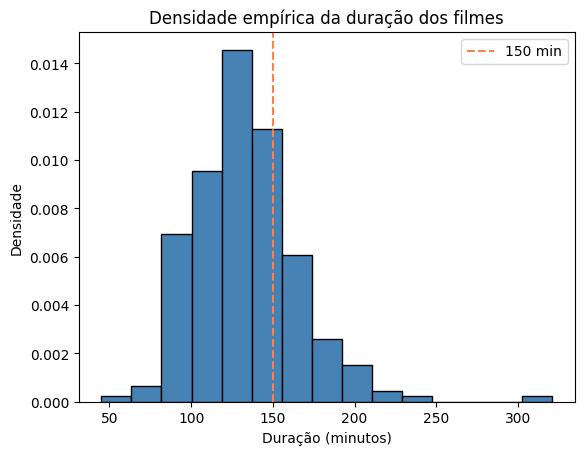

In [27]:
plt.hist(df["runtime_min"], bins=15, density=True, color="steelblue", edgecolor="black")
plt.axvline(150, color="coral", linestyle="--", label="150 min")
plt.xlabel("Duração (minutos)")
plt.ylabel("Densidade")
plt.title("Densidade empírica da duração dos filmes")
plt.legend()
plt.show()

In [28]:
p_runtime_maior_150 = (df["runtime_min"] > 150).mean()
print(f"P(duração > 150 min), empírico = {p_runtime_maior_150:.3f}")

P(duração > 150 min), empírico = 0.264


### Comparando com o modelo "de mentirinha" (uniforme) que usamos na Aula 8

Se a duração fosse *uniformemente* distribuída entre o mínimo e o máximo observados, qual seria essa probabilidade?

In [29]:
minimo, maximo = df["runtime_min"].min(), df["runtime_min"].max()
p_uniforme_hipotetico = (maximo - 150) / (maximo - minimo)

print(f"Se fosse uniforme entre {minimo} e {maximo} min: P(duração > 150) = {p_uniforme_hipotetico:.3f}")
print(f"Valor real (empírico): {p_runtime_maior_150:.3f}")

Se fosse uniforme entre 45 e 321 min: P(duração > 150) = 0.620
Valor real (empírico): 0.264


**A diferença é grande** (modelo uniforme diria ~62%, o real é ~26%) — isso mostra, com dado de verdade, o que a Aula 8 já avisava: o modelo uniforme é só uma simplificação didática. Dados reais quase nunca são uniformes; aqui, a duração se concentra entre 90 e 150 minutos, com poucos filmes bem mais longos puxando o intervalo (mínimo, máximo) para muito além de onde a maioria dos filmes realmente está. Por isso, sempre que possível, é melhor estimar a probabilidade **direto dos dados** (como fizemos) do que assumir um modelo teórico sem checar se ele faz sentido.

In [30]:
esperanca_runtime = df["runtime_min"].mean()
variancia_runtime = df["runtime_min"].var(ddof=0)

print(f"E[duração] = {esperanca_runtime:.1f} min")
print(f"Var[duração] = {variancia_runtime:.1f}")

E[duração] = 133.6 min
Var[duração] = 1020.8


## Fechando: as 8 aulas, uma análise só

| Aula | O que usamos aqui |
|---|---|
| 1 | Classificar variáveis, tabela de frequência, 5 tipos de gráfico, moda/mediana/média |
| 2 | Desvio médio, variância, quantis, box plot, simetria vs. assimetria |
| 3 | Espaço amostral, evento, probabilidade empírica vs. simulada |
| 4 | Arranjo e combinação (`math.perm`, `math.comb`) |
| 5 | Probabilidade condicional (P(A\|B) ≠ P(A) ⇒ dependência) |
| 6 | Probabilidade Total e Teorema de Bayes |
| 7 | Variável aleatória discreta: distribuição, E[X], Var[X] |
| 8 | Variável aleatória contínua: densidade empírica, P(X>150) como área |

Nenhum desses conteúdos é novo — a novidade aqui foi aplicar **todos juntos, numa sequência só, num banco de dados real**, do jeito que uma análise de dados de verdade normalmente acontece: carregar, limpar, descrever, e só depois perguntar coisas mais sofisticadas.

## 🎯 Sugestão de projeto: faça o mesmo com um banco de dados escolhido por você

A proposta é simples de descrever (e trabalhosa de fazer bem — é exatamente por isso que vale a pena): escolha **um banco de dados real** sobre algum assunto que você goste (filme, série, jogo, livro, música, esporte, política, o que for) e refaça, com ele, o mesmo roteiro deste notebook. Isso **não é obrigatório nem vale nota** — é uma sugestão para quem quiser sair da disciplina com uma experiência real de análise de dados no currículo.

### Onde encontrar um banco de dados real
- [Kaggle Datasets](https://www.kaggle.com/datasets) — milhares de bancos de dados prontos para baixar como CSV, sobre praticamente qualquer assunto
- [Dados Abertos do Governo Federal](https://dados.gov.br) e [IBGE SIDRA](https://sidra.ibge.gov.br) — dados públicos brasileiros (educação, saúde, economia, demografia)
- Sites específicos do seu interesse costumam ter dados exportáveis ou páginas de estatísticas (ranking de jogos na Steam, gráficos de streaming, tabelas de campeonato esportivo, etc.) — mesmo copiando uma tabela manualmente para uma planilha, já vale

### O roteiro (o mesmo que seguimos aqui)
1. **Carregar e limpar os dados** — trate valores faltantes, converta texto em número quando precisar (como fizemos com `Runtime` e `Gross`)
2. **Classificar cada variável** — nominal, ordinal, discreta ou contínua
3. **Tabela de frequência e pelo menos 2 gráficos diferentes** para uma variável qualitativa e uma quantitativa
4. **Medidas de posição e dispersão** (média, mediana, desvio médio, variância, quantis) e um **box plot** de alguma variável quantitativa
5. **Defina um experimento aleatório e um evento** de interesse nos seus dados; calcule a probabilidade dele (e confira com uma simulação, como fizemos)
6. **Se fizer sentido**, defina dois eventos e calcule uma probabilidade condicional — e, se possível, aplique o Teorema de Bayes
7. **Construa uma variável aleatória** a partir dos seus dados (discreta ou contínua) e calcule E[X] e Var[X]
8. **Apresente tudo com gráficos e um texto curto interpretando os resultados** — não basta calcular o número, é preciso dizer o que ele significa sobre o fenômeno que você escolheu estudar

Comece pequeno: um banco de dados com 50-300 linhas (como o nosso Top 250) já é suficiente para fazer uma análise completa e interessante. O objetivo não é o tamanho do banco de dados, é passar pelo processo inteiro — da tabela bagunçada até uma conclusão que você consegue defender com números.